# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [33]:
# untuk plot Q-Q
import scipy.stats as stats

In [34]:
df_california = pd.read_csv('california_dataset.csv')

In [35]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

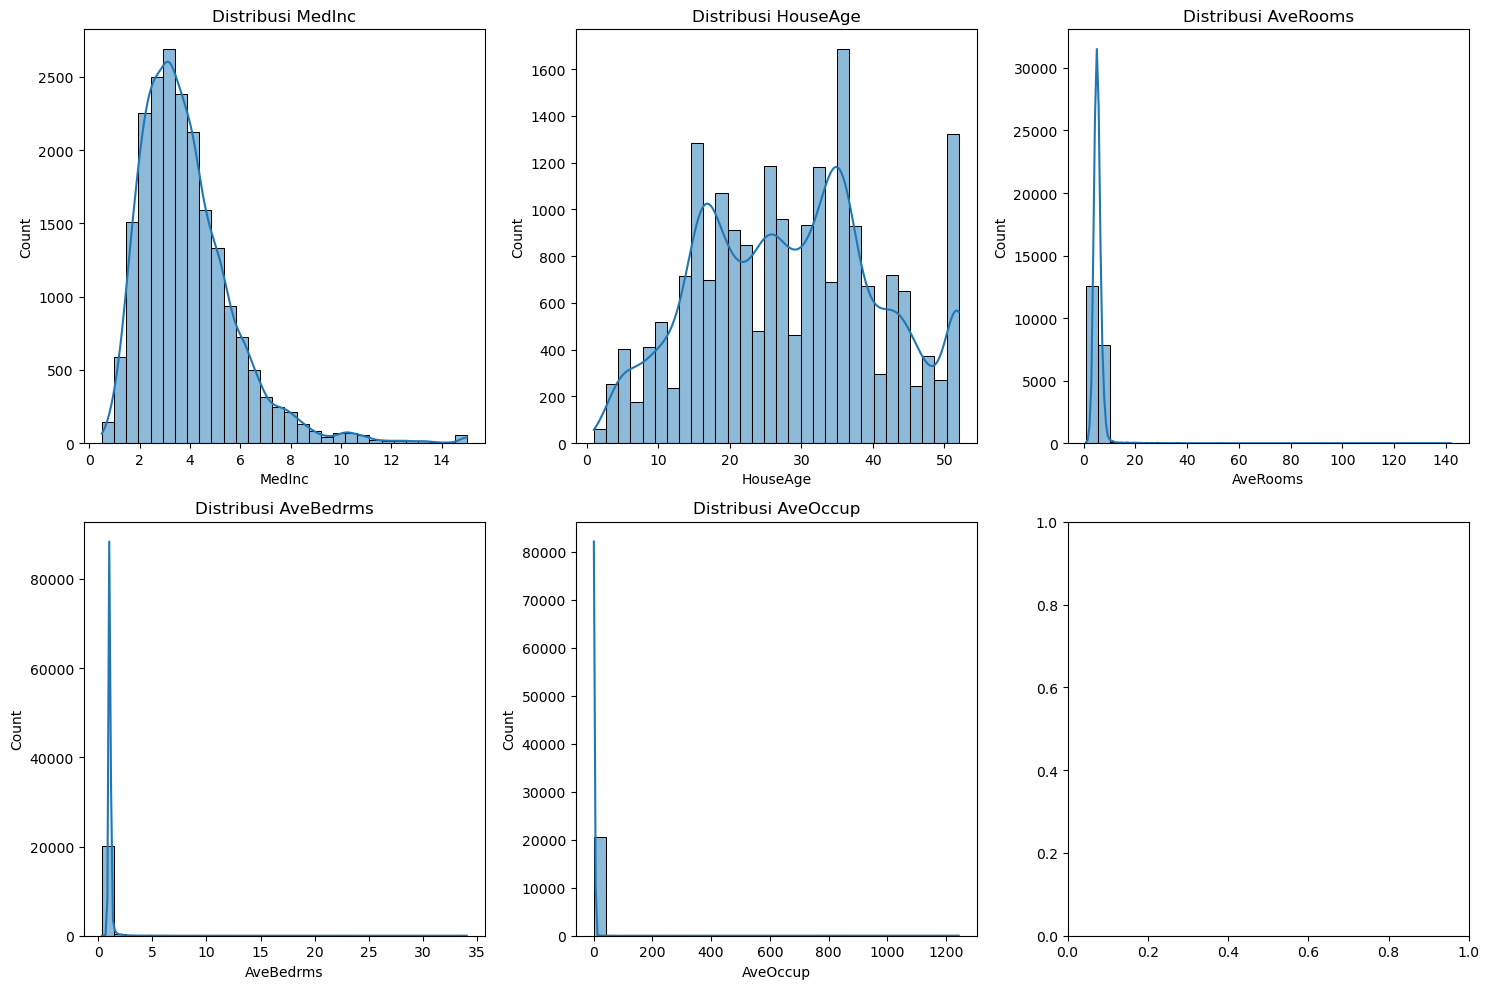

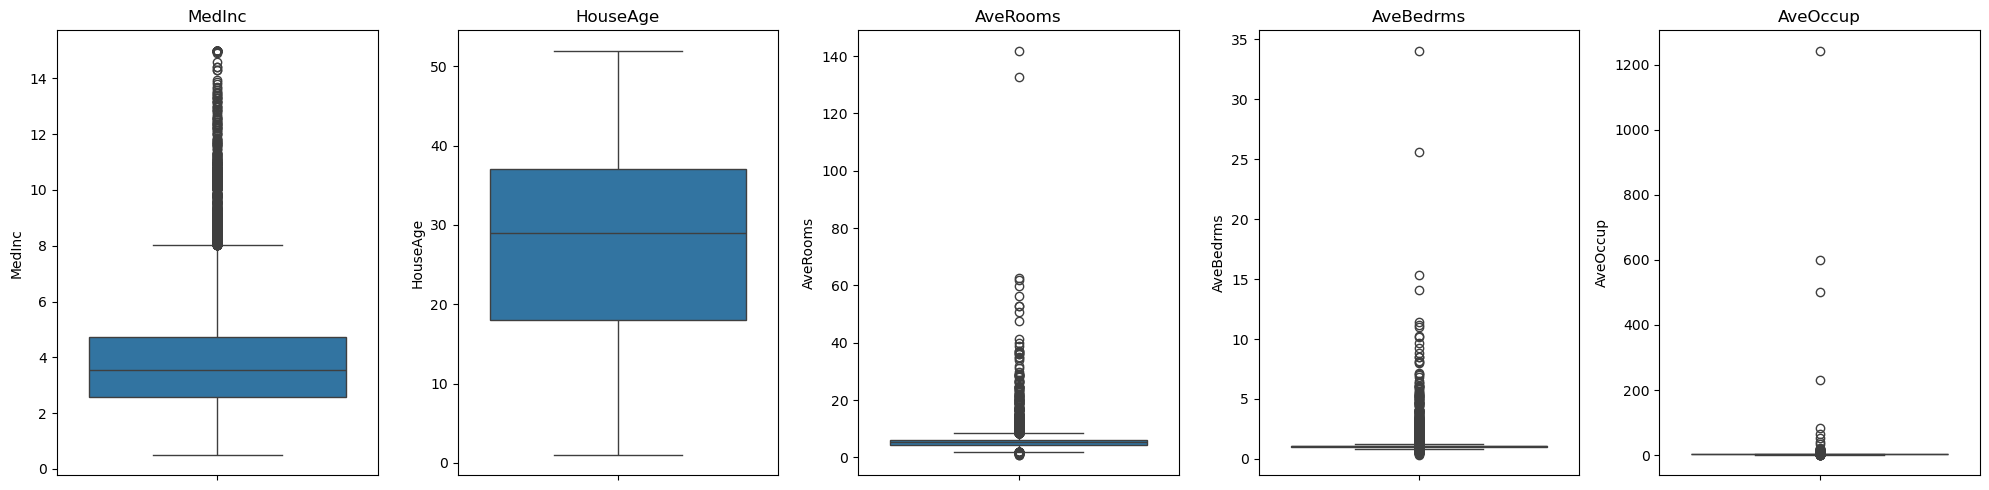

In [36]:
# Daftar nama kolom yang ingin cek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Plot Histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for idx, kolom in enumerate(kolom_kolom):
    sns.histplot(df_california[kolom], bins=30, kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribusi {kolom}')

plt.tight_layout()
plt.show()

# Plot Boxplot
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes = axes.ravel()
for idx, kolom in enumerate(kolom_kolom):
    sns.boxplot(y=df_california[kolom], ax=axes[idx])
    axes[idx].set_title(kolom)

plt.tight_layout()
plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [37]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
# pilih kolom 'MedInc' untuk di-handling
Q1 = df_california['MedInc'].quantile(0.25)
Q3 = df_california['MedInc'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Melakukan Capping (membatasi nilai)
df_california['MedInc'] = df_california['MedInc'].clip(lower=lower_bound, upper=upper_bound)

print("Handling Outlier MedInc Selesai.")

Handling Outlier MedInc Selesai.


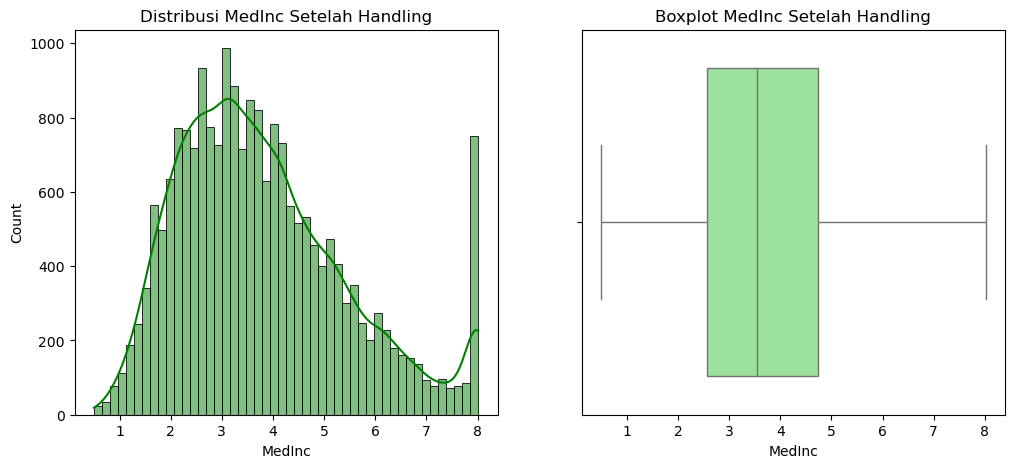

In [38]:
# Melakukan loop untuk mengecek distribusi tiap kolom

# Mengecek kembali distribusi kolom yang sudah di-handling (MedInc)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_california['MedInc'], kde=True, color='green')
plt.title('Distribusi MedInc Setelah Handling')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_california['MedInc'], color='lightgreen')
plt.title('Boxplot MedInc Setelah Handling')
plt.show()


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [39]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [40]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
# Splitting data train dan test (80:20)
df_train, df_test = train_test_split(df_company, test_size=0.2, random_state=42)

print(f"Data Berhasil di split. Jumlah data train: {len(df_train)}")

Data Berhasil di split. Jumlah data train: 537


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [41]:
#Tulis jawaban missing value handling kolom Headquarters disini
# 1. Cek persentase
missing_hq = df_train['Headquarters'].isnull().sum()
total_train = len(df_train)
persentase = (missing_hq / total_train) * 100

print(f"Jumlah Missing Value: {missing_hq}")
print(f"Persentase: {persentase:.2f}%")



Jumlah Missing Value: 0
Persentase: 0.00%


In [42]:
# 2. Cek jenis data
print(f"Tipe data kolom Headquarters: {df_train['Headquarters'].dtype}")

if persentase > 20:
    print("Keputusan: Drop kolom")
else:
    print("Keputusan: Lakukan HANDLING (Imputasi) karena <= 20%")

Tipe data kolom Headquarters: object
Keputusan: Lakukan HANDLING (Imputasi) karena <= 20%


In [43]:
# 3. Melakukan Handling dengan MODUS
modus_hq = df_train['Headquarters'].mode()[0]

# Isi nilai kosong di data train dan test dengan modus dari data train
df_train['Headquarters'] = df_train['Headquarters'].fillna(modus_hq)
df_test['Headquarters'] = df_test['Headquarters'].fillna(modus_hq)

print(f"Handling selesai. Nilai diisi dengan modus: {modus_hq}")
print(f"Sisa missing value di train: {df_train['Headquarters'].isnull().sum()}")

Handling selesai. Nilai diisi dengan modus: New York, NY
Sisa missing value di train: 0


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [ ]:
import pandas as pd
df_churn = pd.read_csv('TelcoCustomerChurn.csv') 

print("Data berhasil masuk ke sistem!")
df_churn.head() # Untuk melihat isi tabelnya

Data berhasil masuk ke sistem!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% untuk latihan dan 20% untuk ujian
df_train, df_test = train_test_split(df_churn, test_size=0.2, random_state=42)

print("Data sudah dipisah menjadi df_train dan df_test")

Data sudah dipisah menjadi df_train dan df_test


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('TelcoCustomerChurn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
# Daftar kolom yang akan diproses
cols_to_fix = [
    'StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 
    'OnlineBackup', 'OnlineSecurity', 'MultipleLines'
]

# Ganti "No internet service" dan "No phone service" menjadi "No"
for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Validasi dengan value_counts untuk memastikan data sudah berubah
for col in cols_to_fix:
    print(f"Value counts untuk {col}:")
    print(df[col].value_counts())
    print("-" * 30)

Value counts untuk StreamingMovies:
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
------------------------------
Value counts untuk StreamingTV:
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
------------------------------
Value counts untuk TechSupport:
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
------------------------------
Value counts untuk DeviceProtection:
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
------------------------------
Value counts untuk OnlineBackup:
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
------------------------------
Value counts untuk OnlineSecurity:
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
------------------------------
Value counts untuk MultipleLines:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64
------------------------------


In [57]:
# Inisialisasi LabelEncoder
le = LabelEncoder()

# Melakukan transformasi pada setiap kolom di dalam list
for col in cols_to_fix:
    df[col] = le.fit_transform(df[col])

# Menampilkan hasil akhir dalam bentuk angka (0 atau 1)
print("Hasil setelah Label Encoder:")
df[cols_to_fix].head()

Hasil setelah Label Encoder:


,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,0,0,0,0,1,0,0
1,0,0,0,1,0,1,0
2,0,0,0,0,1,1,0
3,0,0,1,1,0,1,0
4,0,0,0,0,0,0,0


## Selesai :)